In [1]:
# make top level dir available
import sys
sys.path.append("../../")

import numpy as np
import functions as myfunc
import meshtools as mt
import matplotlib.pyplot as plt
import scipy as sci

## Load Data

In [2]:
# custom values
EDGE_LENGTH = 1e-2 
EDGE_OFFSET = 1e-3 

# given paramters
RA = 0.3
DD = 0.01
HM = 0.08
BM = 0.08
MA = 0.01
MB = 0.05
RM0 = 0.095
ZM0 = 0.0
LLS = 0.001
SD = 0.005
SH = 0.01

## Define Functions and Paramters

For the general linear differential equation 

\begin{equation}
-\frac{\partial}{\partial x}\left(\alpha_1(x, y) \frac{\partial \Phi(x, y)}{\partial x}\right)-\frac{\partial}{\partial y}\left(\alpha_2(x, y) \frac{\partial \Phi(x, y)}{\partial y}\right)+\beta(x, y) \Phi(x, y)=f(x, y)
\end{equation}

we substitue the generic functions with the given terms. Additionally, some parameters are set.

In [ ]:
def _magnetic_pernmability(x, y):
    MU_1 = 10
    MU_2 = 10

    if 0 < x < DD and -HM/2 < y < HM/2: # material 1, left layer
        mu = MU_1    
    elif 0 < x < BM-DD and -HM/2 < y < -HM/2+DD:    # material 1, bottom layer
        mu = MU_1   
    elif 0 < x < BM-DD and HM/2-DD < y < HM/2:  # material 1, top layer
        mu = MU_1   
    elif BM-DD < x < BM and -HM/2 < y < HM/2:   # material 2
        mu = MU_2    
    else:   # outside material
        mu = 0

    return sci.constants.mu_0 * mu

def alpha1(x, y):
    mu =  _magnetic_pernmability(x, y)
    # if np.isclose(x, 0) or np.isclose(mu, 0):    # TODO: this is probably not a good solution
    #     return 0
    # else:
    return 1 / (mu  * x) 

def alpha2(x, y):
    return alpha1(x, y)

def beta(x, y):
    return 0

def rhs(x, y):
    # mag_diff_r = - M0 * 2 / MA * 6 * (x - RM0)**5
    # mag_diff_z = - M0 * 2 / MB * 6 * (y - ZM0)**5
    mag_diff_r = 0
    mag_diff_z = 0
    
    return _current_density(x, y) + mag_diff_r + mag_diff_z

def _current_density(x, y):
    # Coil 1
    CURRENT_1 = 1     # Ampere
    AREA_COIL_1 = SD * 2 * SH

    # Coil 2
    CURRENT_2 = 0
    AREA_COIL_2 = SH * SD

    # check if x,y are inside coil 1/2
    if DD+LLS < x < DD+LLS+SD and -SH < y < SH:      
        return CURRENT_1 / AREA_COIL_1
    elif BM-LLS-SD < x < BM-LLS and -SH/2 < y < SH/2:
        return CURRENT_2 / AREA_COIL_2 
    else:
        return 0

## Boundaray Condtions

### Dirichlet Boundary

For all points inside the area $G_D$ the solution value $\Phi$ is known.

\begin{equation}

    \Phi(x,y) = \delta(x,y) \quad x,y \in G_D

\end{equation}

### Robin Boundary

For all points inside the area $G_R$ the solution and its partial derivates are restricted.

\begin{equation}

    \left( \alpha_1(x,y) \frac{\partial \Phi(x, y)}{\partial x}, \alpha_2(x,y) \frac{\partial \Phi(x,y)}{\partial y} \right) \cdot \vec{n} + \gamma(x,y) \Phi(x,y) = \rho(x,y)

    \\ \quad

    x,y \in G_R

\end{equation}

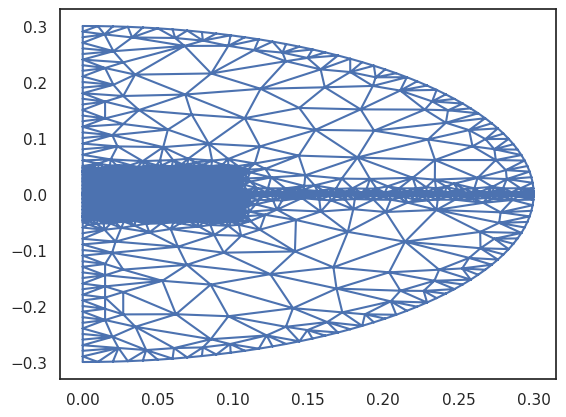

In [4]:
nodes, elements, boundary_edge, boundary_inidces, boundary_elements, outer_curve, inner_curve = mt.LoadTriMesh("Loesung_FEM_WS1920/KlausurWS1920_Netz.npz", show=True)

In [5]:
#______________
# Dirichlet Boundary
def dirichlet_func(x, y):
    return 0

# all knots where r=0
DIRICHLET_INDICES = np.array(mt.RetrieveSegments(nodes, boundary_edge, boundary_inidces, [[0, RA], [0, -RA]], ["Nodes"])).flatten()

#______________
# Robin Boundary
def robin_gamma(x, y):
    mu = _magnetic_pernmability(x, y)
    if np.isclose(x, 0) or np.isclose(y, 0) or np.isclose(mu, 0):  # TODO: this is a hacky solution. handle the robin indicies creation better! 
        return 0
    return 1 / ( mu * x * np.sqrt(np.power(x, 2) + np.power(y, 2)) )

def robin_rhs(x, y):
    return 0

# robin indices should be all segments of the the half circle
BOUNDARY_POINTS = [[0,-RA],[RA, 0],[0,RA]]
ROBIN_INDICES = mt.RetrieveSegments(nodes, boundary_edge, boundary_inidces,BOUNDARY_POINTS, ["Segments", "Segments"])
ROBIN_INDICES = ROBIN_INDICES = np.array(ROBIN_INDICES[0] + ROBIN_INDICES[1])

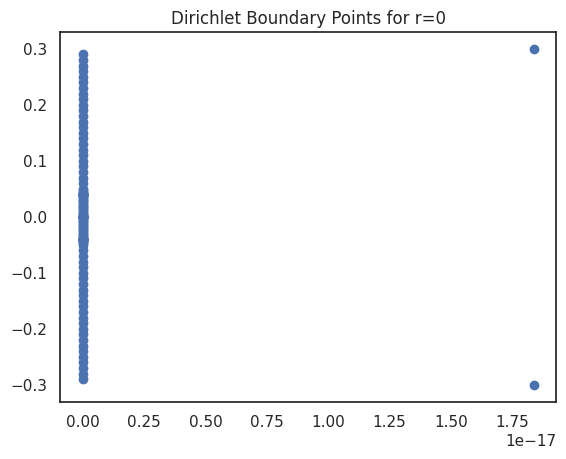

In [6]:
plt.scatter(nodes[DIRICHLET_INDICES][:,0], nodes[DIRICHLET_INDICES][:,1])

plt.title("Dirichlet Boundary Points for r=0")
plt.show()

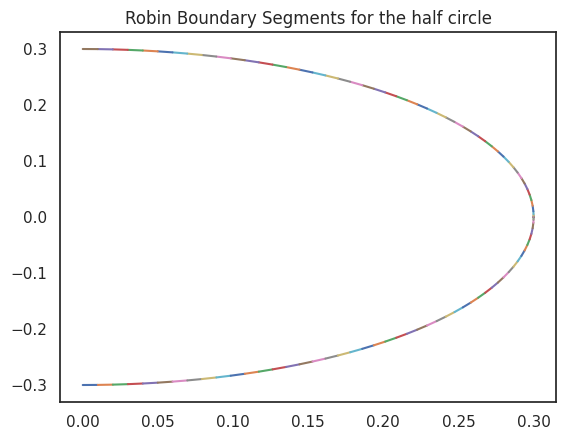

In [7]:
fig, ax = plt.subplots()
for segment in nodes[ROBIN_INDICES]:
    x_val = [segment[0,0], segment[1,0]]
    y_val = [segment[0,1], segment[1,1]]

    ax.plot(x_val, y_val)

plt.title("Robin Boundary Segments for the half circle")
plt.show()

## Solve 2D FEM

In [8]:
stiffness_matrix, load_vector = myfunc.assemble_global_system(nodes, elements, alpha1, alpha2, beta, rhs)
stiffness_matrix, load_vector = myfunc.insert_robin_values(nodes, stiffness_matrix, load_vector, ROBIN_INDICES, robin_gamma, robin_rhs)
stiffness_matrix, load_vector = myfunc.insert_dirichlet_values(nodes, stiffness_matrix, load_vector, DIRICHLET_INDICES, dirichlet_func)

                 x         y           Phi
0     1.836970e-17 -0.300000  0.000000e+00
1     1.002449e-02 -0.299832  1.473240e-24
2     2.003779e-02 -0.299330  6.850168e-24
3     3.002871e-02 -0.298493 -1.681500e-23
4     3.998609e-02 -0.297323 -1.245464e-23
...            ...       ...           ...
4451  1.247503e-01 -0.143146 -7.750992e-20
4452  1.938730e-01  0.113085  6.428225e-22
4453  1.440581e-01  0.153683 -2.141844e-21
4454  1.183380e-01  0.187872  9.985268e-23
4455  5.663119e-02  0.114936 -2.381835e-19

[4456 rows x 3 columns]


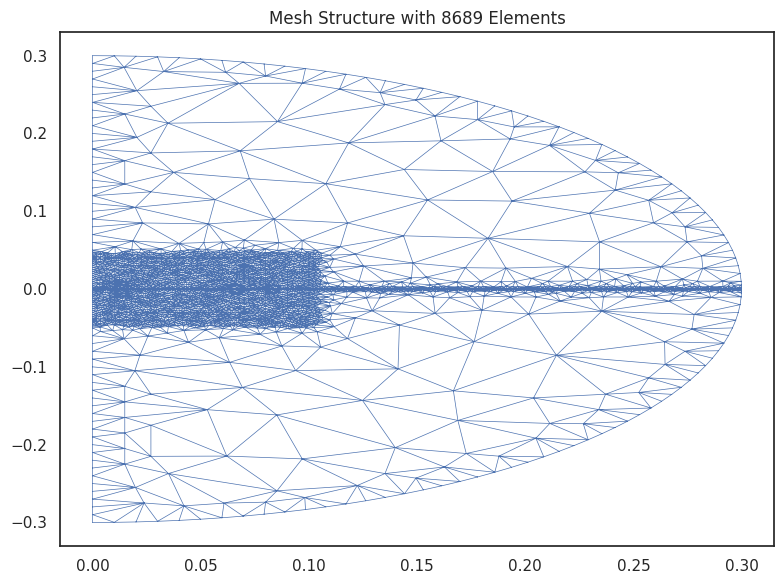

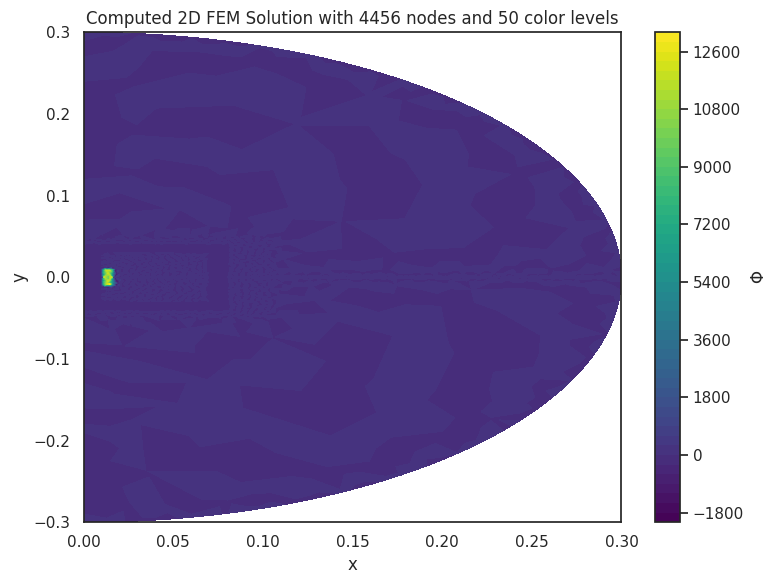

In [9]:
solution = myfunc.solve_system(nodes, stiffness_matrix, load_vector)
print(solution)
myfunc.plot_result(elements, solution, levels=50)